# 01 — Uncertainty Validation (Section 5.1)

The quantile-regression volatility model (`forecasting/quantile_volatility.py`) produces a p10/p50/p90 band per prediction. The p90-p10 spread is meant to be **epistemic uncertainty** — how sure the model is about *this* forecast — and it feeds the API's `confidence` field.

**A band is only worth anything if it tracks real error.** A wide band must actually mean a less reliable prediction; otherwise `confidence` is decorative and, worse, misleading if anyone acts on it. This notebook is the honesty gate: fit the quantile model with proper walk-forward, then check that out-of-sample error rises with band width. If it does not, the confidence field does not ship.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
# Ensure the project root is on the import path so `src` can be imported.
project_root = Path.cwd().resolve()
for candidate in (project_root, *project_root.parents):
    if (candidate / "src").exists():
        sys.path.insert(0, str(candidate))
        break

from src.forecast_engine.features.schema import FEATURE_NAMES
from src.forecast_engine.evaluation.splits import walk_forward_splits
from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features
from src.forecast_engine.forecasting.quantile_volatility import (
    QuantileVolatilityModel,
    TARGET_COLUMN,
    validate_uncertainty,
)

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)
feature_cols = [c for c in FEATURE_NAMES if c in data.columns and not data[c].isna().all()]

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f"Dates: {data['date'].min().date()} to {data['date'].max().date()}")
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Dates: 2021-07-19 to 2026-07-17
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,treasury_2y,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,0.21,0.1,0.903614,0.98,6.17,NaN,-0.16,6.48,NaN,-0.24
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,0.20,0.1,0.850431,1.03,2.72,NaN,-0.05,3.90,NaN,-0.17
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,0.22,0.1,0.818930,1.08,-0.54,NaN,0.02,2.43,NaN,-0.15
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,0.20,0.1,0.809241,1.07,-0.76,NaN,0.01,2.62,NaN,-0.13
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,0.22,0.1,0.794457,1.08,-1.25,NaN,0.02,2.13,NaN,-0.12


## Out-of-sample band and error

The quantile model is fit walk-forward, exactly like the point model in 08b, and its p10/p50/p90 are predicted on each out-of-sample fold. The purge gap matches the target horizon so no training target overlaps the test window.

In [3]:
PURGE_DAYS = 5   # match the future_realized_vol horizon

model_data = data.dropna(subset=feature_cols + [TARGET_COLUMN]).reset_index(drop=True)

oos_frames = []
for fold, (train_idx, test_idx) in enumerate(
        walk_forward_splits(model_data, purge_days=PURGE_DAYS), start=1):
    model = QuantileVolatilityModel(feature_cols, schema_version="2.2")
    model.fit(model_data.loc[train_idx])
    preds = model.predict(model_data.loc[test_idx])
    block = preds.copy()
    block["actual"] = model_data.loc[test_idx, TARGET_COLUMN].to_numpy()
    oos_frames.append(block)
    print(f"fold {fold} done")

oos = pd.concat(oos_frames, ignore_index=True)
oos["band_width"] = oos["p90"] - oos["p10"]
oos["abs_error"] = (oos["actual"] - oos["p50"]).abs()
print(f"\nout-of-sample predictions: {len(oos):,}")

fold 1 done
fold 2 done
fold 3 done

out-of-sample predictions: 388,546


## ★ The honesty gate

`validate_uncertainty` buckets predictions by band width and reports mean error per bucket, the width-error correlation, and whether error rises monotonically. **`is_valid` must be True to ship the confidence field.**

In [4]:
report = validate_uncertainty(oos[["p10", "p50", "p90"]], oos["actual"])

print(f"correlation(band width, abs error): {report['correlation_width_error']:+.3f}")
print(f"widest / narrowest error ratio    : {report['widest_vs_narrowest_error_ratio']:.2f}")
print(f"monotone increasing               : {report['monotone_increasing']}")
print(f"\nmean abs error by uncertainty bucket:")
for bucket, err in report["error_by_bucket"].items():
    print(f"  bucket {bucket}: {err:.5f}")

print(f"\nIS VALID (ship the confidence field?): {report['is_valid']}")
if not report["is_valid"]:
    print("  -> The band does NOT reliably track error. Do not wire confidence to")
    print("     anything user-facing until this passes on real data.")

correlation(band width, abs error): +0.360
widest / narrowest error ratio    : 2.67
monotone increasing               : True

mean abs error by uncertainty bucket:
  bucket 0: 0.00401
  bucket 1: 0.00505
  bucket 2: 0.00639
  bucket 3: 0.01070

IS VALID (ship the confidence field?): True


empirical coverage of [p10, p90]: 78.9%  (nominal 80%)


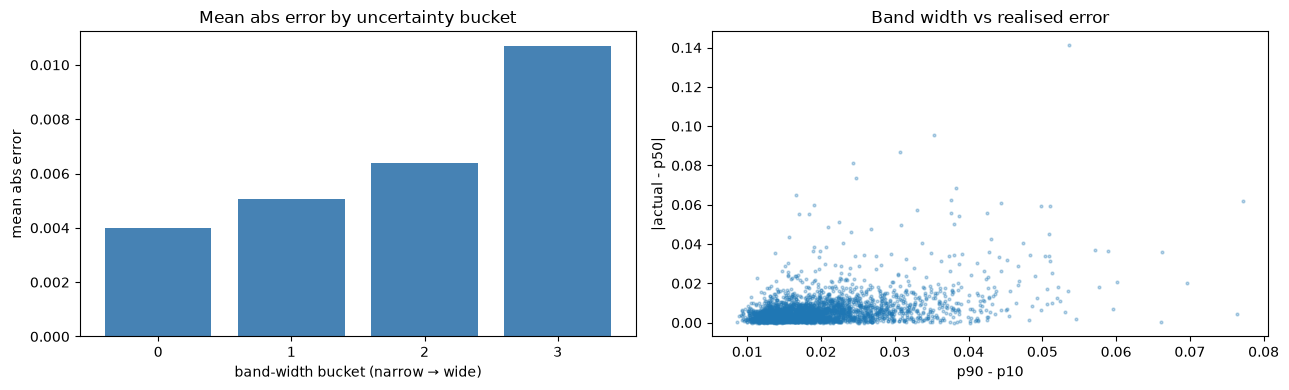

In [5]:
# Coverage: ~80% of actuals should fall inside [p10, p90].
inside = ((oos["actual"] >= oos["p10"]) & (oos["actual"] <= oos["p90"])).mean()
print(f"empirical coverage of [p10, p90]: {inside:.1%}  (nominal 80%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bucket_means = pd.Series(report["error_by_bucket"])
axes[0].bar(bucket_means.index.astype(str), bucket_means.values, color="steelblue")
axes[0].set_title("Mean abs error by uncertainty bucket")
axes[0].set_xlabel("band-width bucket (narrow → wide)")
axes[0].set_ylabel("mean abs error")

sample = oos.sample(min(3000, len(oos)), random_state=0)
axes[1].scatter(sample["band_width"], sample["abs_error"], s=4, alpha=0.3)
axes[1].set_title("Band width vs realised error")
axes[1].set_xlabel("p90 - p10"); axes[1].set_ylabel("|actual - p50|")
plt.tight_layout(); plt.show()

## Conclusions

**If `is_valid` is True and error rises across buckets:** the uncertainty band is real. The `confidence` field can ship, and the wider-band-means-less-trust interpretation is justified. Downstream uses (a confidence display, `sigma_total = sqrt(sigma_market^2 + epistemic^2)`, or gating a low-confidence forecast back to historical drift) are then defensible.

**If `is_valid` is False:** the band is noise. Do not ship the confidence field. This is the same discipline as the rest of the project — the uncertainty signal earns its place only by passing a check, exactly as the return signal had to and the macro features failed to.

**Coverage note:** empirical coverage near 80% confirms the quantiles are roughly calibrated in level, not just in ordering. Materially below 80% means the bands are too narrow (overconfident); above means too wide (underconfident). Either is worth noting alongside the validity verdict.